In [ ]:
#%%capture
#%tensorflow_version 2.x
!pip install tensorflow==2.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.8/511.8 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 71.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.7/438.7 kB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 79.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 50.8 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 24.3.25
    Uninstalling flatbuffers-24.3.25:
      Successfully uninstalled flatbuffers-24.3.25
  Attempting uninstall: tensorboard-data-serve

In [ ]:
import tensorflow as tf
!python --version                     # mostrar version de python
print('Tensorflow ' + tf.__version__) # mostrar version tensorflow

Python 3.10.12
Tensorflow 2.9.2


In [ ]:
import os, subprocess

# Montar Google Drive y crear carpetas
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

work_dir = '/content/work_dir'                    # directorio de trabajo en local (mas rapido)
dwld_dir = '/content/gdrive/My Drive/dwld_dir'    # directorio de descarga en Google drive personal
subprocess.call(["mkdir","-p",work_dir])          # crear directorio para trabajo
subprocess.call(["mkdir","-p",dwld_dir+'/dataset/'])  # crear directorio para dataset

os.chdir(dwld_dir+'/dataset/')                        # posicionarse en el directorio
# Descargar dataset scenes15 si no esta disponible
if os.path.isfile('./dataset_scenes15.zip') == False:
  !wget http://www-vpu.eps.uam.es/~jcs/tsv/dataset_scenes15.zip

# Copiar el dataset al directorio local (mayor velocidad de lectura que en Gdrive)
!cp /content/gdrive/My\ Drive/dwld_dir/dataset/dataset_scenes15.zip /content/work_dir/

os.chdir(work_dir)                        # posicionarse en el directorio
if os.path.isdir('./scenes15') == False:
  !unzip -o -q dataset_scenes15.zip -d .

print('El dataset se encuentra descargado en el directorio {} \ny descomprimido en el directorio {} (usado para lectura de datos)'.format(dwld_dir, work_dir))

Mounted at /content/gdrive
El dataset se encuentra descargado en el directorio /content/gdrive/My Drive/dwld_dir 
y descomprimido en el directorio /content/work_dir (usado para lectura de datos)


In [ ]:
# esta directiva genera un fichero con el codigo escrito a continuacion
import tensorflow as tf
import pathlib
import numpy as np

def crear_generadores(batch_size, img_height, img_width):
    dataset_dir = pathlib.Path(work_dir + '/scenes15/')

    # Obtener etiquetas de clase y numero de clases
    CLASS_NAMES = np.array([item.name for item in dataset_dir.glob('*')]) #clases son subdirectorios de '/train/'
    NUM_CLASSES = len(CLASS_NAMES) # numero total de clases

    # Crear ImageDataGenerator convirtiendo de uint8 a float32 en el rango [0,1].
    img_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, validation_split=0.20)

    # Obtenemos un iterador sobre los datos de entrenamiento del dataset
    # aplicando el ImageDataGenerator creado anteriormente
    BATCH_SIZE = batch_size # numero de elementos procesados conjuntamente en cada iteracion
    IMG_HEIGHT = img_height
    IMG_WIDTH = img_width
    IMG_CHANNELS = 3
    train_data_gen = img_gen.flow_from_directory(directory=str(dataset_dir),
                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                              color_mode='rgb',
                                              classes = list(CLASS_NAMES),
                                              class_mode='categorical',
                                              batch_size=BATCH_SIZE,
                                              subset="training",
                                              shuffle=True,
                                              seed=0)

    test_data_gen = img_gen.flow_from_directory(directory=str(dataset_dir),
                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                              color_mode='rgb',
                                              classes = list(CLASS_NAMES),
                                              class_mode='categorical',
                                              batch_size=BATCH_SIZE,
                                              subset="validation",
                                              shuffle=True,
                                              seed=0)

    return train_data_gen, test_data_gen, NUM_CLASSES

In [ ]:
# esta directiva genera un fichero con el codigo escrito a continuacion
import tensorflow.keras.layers as layers
import tensorflow.keras.models as models
import tensorflow.keras.optimizers as optimizers

def generar_red(num_classes, img_height, img_width, learning_rate, activation_function='relu', img_channels=3):

    # definir modelo de red
    model = models.Sequential()

    # incluir capa convolucional C1
    model.add(layers.Conv2D(filters=6,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation=activation_function,
                          input_shape=(img_height,img_width,img_channels)))

    # incluir average pooling S2
    model.add(layers.AveragePooling2D())

    # incluir capa convolucional C3
    model.add(layers.Conv2D(filters=16,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation=activation_function))

    # incluir average pooling S4
    model.add(layers.AveragePooling2D())

    # convertir el volumen de datos en vector fila para conectarlo con capa FC
    model.add(layers.Flatten())

    # incluir fully convolutional F5
    model.add(layers.Dense(units=120, activation=activation_function))

    # incluir fully convolutional F6
    model.add(layers.Dense(units=84, activation=activation_function))

    # incluir salida OUTPUT
    model.add(layers.Dense(units=num_classes, activation = 'softmax'))

    # definicion con optimizador con valores definidos por el usuario
    model.compile(optimizer=optimizers.SGD(learning_rate=learning_rate),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    return model

In [ ]:
import time

def entrenamiento(model, batch_size, epochs, train_data_gen, test_data_gen, verbose=1):

    stime = time.time() # medida inicial de tiempo


    #si tiene problemas al ejecutar con la GPU,
    # descomente la siguiente linea para utilizar la CPU
    # y comente la linea que selecciona la GPU
    #with tf.device('/CPU:0'):
    with tf.device('/GPU:0'):
      history = model.fit_generator(
          generator=train_data_gen,
          steps_per_epoch=train_data_gen.n // batch_size,
          validation_data=test_data_gen,
          validation_steps=test_data_gen.n // batch_size,
          epochs=epochs,
          verbose=verbose
      )

    ftime = time.time() # medida final de tiempo
    #print('Entrenamiento terminado {} secs' .format(ftime-stime))

    return history, ftime-stime

In [ ]:
import time

def test(tets_data_gen, batch_size, verbose):
    stime = time.time() # medida inicial de tiempo

    #si tiene problemas al ejecutar con la GPU,
    # descomente la siguiente linea para utilizar la CPU
    # y comente la linea que selecciona la GPU
    #with tf.device('/CPU:0'):
    with tf.device('/GPU:0'):
      test_loss, test_acc = model.evaluate_generator(generator=test_data_gen,
                                                    steps = test_data_gen.n // batch_size,
                                                    verbose=verbose)

    ftime = time.time() # medida final de tiempo
    #print('Test terminado {} secs' .format(ftime-stime))

    return test_loss, test_acc, ftime-stime

In [ ]:
import matplotlib.pyplot as plt

def mostrar_resultados(history, title='Training and Validation Accuracy'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    EPOCHS = len(acc)


    plt.figure(figsize=(8, 8))
    plt.subplot(2,1, 1)
    plt.plot(range(EPOCHS), acc, label='Rendimiento train (accuracy)')
    plt.plot(range(EPOCHS), val_acc, label='Rendimiento validacion (accuracy)')
    plt.legend(loc='upper left')
    plt.title(title)

    plt.subplot(2,1, 2)
    plt.plot(range(EPOCHS), loss, label='Pérdidas entrenamiento (Loss)')
    plt.plot(range(EPOCHS), val_loss, label='Pérdidas validacion (Loss)')
    plt.legend(loc='upper left')
    plt.title('Training and Validation Loss')
    plt.xlabel('# epoca')

    plt.show()

Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/50


<ipython-input-18-0ca46b694a29>:13: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


449/449 [==============================] - 7s 14ms/step - loss: 2.6806 - accuracy: 0.1024 - val_loss: 2.6640 - val_accuracy: 0.1025
Epoch 2/50
449/449 [==============================] - 6s 14ms/step - loss: 2.6126 - accuracy: 0.1381 - val_loss: 2.6167 - val_accuracy: 0.1329
Epoch 3/50
449/449 [==============================] - 8s 18ms/step - loss: 2.5160 - accuracy: 0.1746 - val_loss: 2.5566 - val_accuracy: 0.1464
Epoch 4/50
449/449 [==============================] - 6s 14ms/step - loss: 2.4346 - accuracy: 0.2027 - val_loss: 2.4960 - val_accuracy: 0.2207
Epoch 5/50
449/449 [==============================] - 8s 18ms/step - loss: 2.3537 - accuracy: 0.2327 - val_loss: 2.4271 - val_accuracy: 0.2173
Epoch 6/50
449/449 [==============================] - 6s 14ms/step - loss: 2.2691 - accuracy: 0.2631 - val_loss: 2.4006 - val_accuracy: 0.2466
Epoch 7/50
449/449 [==============================] - 8s 17ms/step - loss: 2.1870 - accuracy: 0.2806 - val_loss: 2.2807 - val_accuracy: 0.2568
Epoch 8/50

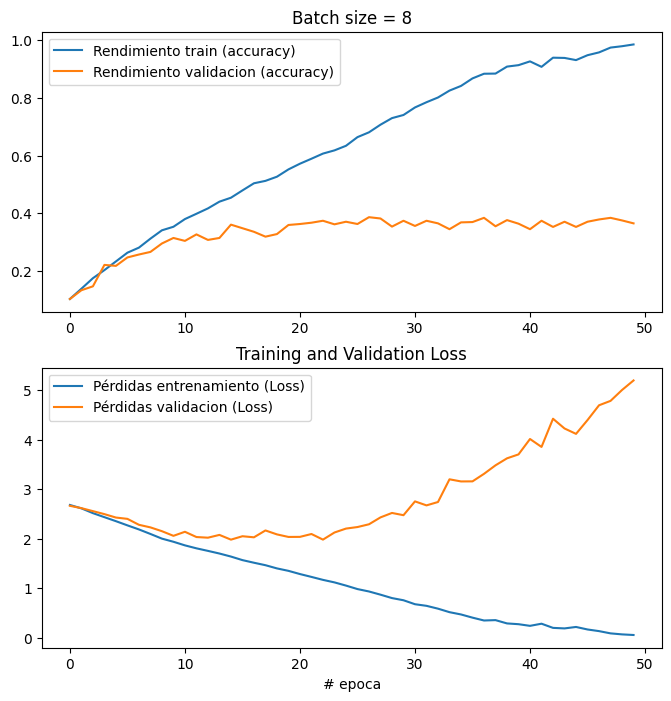

Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/50
224/224 [==============================] - 6s 26ms/step - loss: 2.6968 - accuracy: 0.0889 - val_loss: 2.6807 - val_accuracy: 0.0966
Epoch 2/50
224/224 [==============================] - 7s 31ms/step - loss: 2.6525 - accuracy: 0.1155 - val_loss: 2.6525 - val_accuracy: 0.1330
Epoch 3/50
224/224 [==============================] - 7s 32ms/step - loss: 2.5978 - accuracy: 0.1351 - val_loss: 2.6103 - val_accuracy: 0.1239
Epoch 4/50
224/224 [==============================] - 6s 27ms/step - loss: 2.5488 - accuracy: 0.1563 - val_loss: 2.5830 - val_accuracy: 0.1341
Epoch 5/50
224/224 [==============================] - 7s 33ms/step - loss: 2.4997 - accuracy: 0.1720 - val_loss: 2.5588 - val_accuracy: 0.1682
Epoch 6/50
224/224 [==============================] - 7s 30ms/step - loss: 2.4531 - accuracy: 0.1977 - val_loss: 2.5491 - val_accuracy: 0.1659
Epoch 7/50
224/224 [==============================] - 6s 

In [ ]:
batch_size = 8
epochs = 25
img_size_list = 32
learning_rate = 0.01
activation_function_list =['relu', 'tanh', 'sigmoid']
time_list = []
final_train_loss = []
final_train_acc = []
final_val_loss = []
final_val_acc = []

for activation_function in activation_function_list:
    train_data_gen, test_data_gen, num_classes = crear_generadores(batch_size, img_size, img_size)
    model = generar_red(num_classes, img_size, img_size, activation_function=activation_function, learning_rate=learning_rate)
    history, train_time = entrenamiento(model, batch_size, epochs, train_data_gen, test_data_gen)
    # Pérdida y exactitud final de entrenamiento
    final_train_loss.append(history.history['loss'][-1])
    final_train_acc.append(history.history['accuracy'][-1])

    # Pérdida y exactitud final de validación
    final_val_loss.append(history.history['val_loss'][-1])
    final_val_acc.append(history.history['val_accuracy'][-1])
    time_list.append(train_time)
    mostrar_resultados(history, title='Función de activación = {}'.format(activation_function))

In [ ]:
# Crear la figura y el eje principal
fig, ax1 = plt.subplots(figsize=(10, 6))

# Ejes principales para accuracy y loss
ax1.set_xlabel('Función de activación')
ax1.set_ylabel('Accuracy / Loss', color='blue')
ax1.plot(activation_function_list, final_train_acc, marker='o', label='Train Accuracy', color='blue', linestyle='-')
ax1.plot(activation_function_list, final_val_acc, marker='o', label='Test Accuracy', color='blue', linestyle='--')
ax1.plot(activation_function_list, final_train_loss, marker='o', label='Train Loss', color='red', linestyle='-')
ax1.plot(activation_function_list, final_val_loss, marker='o', label='Test Loss', color='red', linestyle='--')
ax1.tick_params(axis='y', labelcolor='blue')

# Ejes secundarios para tiempos de entrenamiento
ax2 = ax1.twinx()
ax2.set_ylabel('Tiempo (s)', color='green')
ax2.plot(activation_function_list, time_list, marker='o', label='Training Time', color='green', linestyle='-')
ax2.tick_params(axis='y', labelcolor='green')

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Título y mostrar gráfico
plt.title('Impacto de la función de activación en Métricas y Tiempo')
plt.show()